Load the results into a DataFrame

In [62]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

with open("./eval_results.json") as eval_results:
    data = json.load(eval_results)

df = pd.DataFrame(data["results"])
answerable = df[~df["abstain"]].copy()

FULL = "rrf + company + table routing"
full = answerable[answerable["config"] == FULL]

order = ["embed only", "rrf only", "encoder only", "rrf + company + table routing"]


Comparing recall, completeness and MRR values after different strategies

In [80]:
print("total answerable:", len(full))
answerable.groupby("config")[["recall", "completeness", "mrr"]].mean().round(3).reindex(order)

total answerable: 95


,recall,completeness,mrr
config,,,
embed only,0.632,0.589,0.392
rrf only,0.667,0.621,0.479
encoder only,0.751,0.705,0.531
rrf + company + table routing,0.835,0.779,0.612


Comparison by Company

In [ ]:
full.explode("companies").groupby("companies").agg(
    n=("id", "count"),
    recall=("recall", "mean"),
    completeness=("completeness", "mean")
).round(3)

,n,recall,completeness
companies,,,
amd,13,0.833,0.692
axp,9,0.500,0.444
cop,10,0.750,0.700
cvx,9,0.833,0.778
goog,11,0.712,0.636
jnj,12,0.958,0.917
ko,14,0.786,0.643
meta,9,0.833,0.778
nvda,14,0.810,0.714


Comparison by hop (Single Chunk, Multi Chunk - Same Doc, Multi Doc)

In [ ]:
full.groupby("hop").agg(
    n=("id", "count"),
    recall=("recall", "mean"),
    completeness=("completeness", "mean"),
    mrr=("mrr", "mean")
).round(3)

,n,recall,completeness,mrr
hop,,,,
multi_chunk,11,0.727,0.636,0.576
multi_doc,17,0.608,0.353,0.529
single,67,0.910,0.910,0.639


Comparison by difficulty

In [85]:
# full.groupby("difficulty")[["recall", "completeness", "mrr"]].mean().round(3)
full.groupby("difficulty").agg(
    n=("id", "count"),
    recall=("recall", "mean"),
    completeness=("completeness", "mean"),
    mrr=("mrr", "mean")
).round(3)

,n,recall,completeness,mrr
difficulty,,,,
easy,29,0.845,0.828,0.633
hard,20,0.692,0.550,0.544
medium,46,0.891,0.848,0.628


Comparison by Question Type

In [87]:
full.groupby("type").agg(
    n=("id", "count"),
    recall=("recall", "mean"),
    completeness=("completeness", "mean"),
    mrr=("mrr", "mean")
).round(3)

,n,recall,completeness,mrr
type,,,,
comparison,10,0.583,0.300,0.554
distractor,2,1.000,1.000,0.667
event,8,1.000,1.000,0.742
factoid,37,0.865,0.865,0.659
risk,13,1.000,1.000,0.686
table,25,0.740,0.640,0.481


In [86]:
answerable.pivot_table(index="type", columns="config", values="recall", aggfunc="mean").round(3).reindex(order, axis=1)

config,embed only,rrf only,encoder only,rrf + company + table routing
type,,,,
comparison,0.533,0.383,0.583,0.583
distractor,1.000,1.000,1.000,1.000
event,0.875,0.875,1.000,1.000
factoid,0.775,0.784,0.865,0.865
risk,0.692,0.846,1.000,1.000
table,0.320,0.420,0.420,0.740


Rank Distribution

10


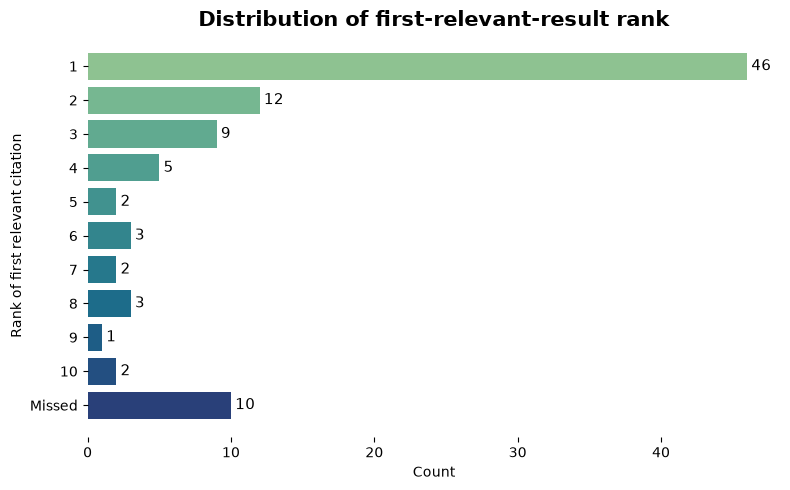

In [ ]:

non_zero_mrr = full[full["mrr"] != 0]
completely_missed = len(full) - len(non_zero_mrr)
print(completely_missed)
ranks = 1 / non_zero_mrr["mrr"]
rounded_ranks = np.ceil(ranks)


counts = rounded_ranks.value_counts().sort_index()
# add the missed count as its own category on the same series
counts.index = counts.index.astype(int).astype(str)  # "1", "2", "3"... as labels
counts["Missed"] = completely_missed

fig, ax = plt.subplots(figsize=(8, 5))

# horizontal bars = chart rotated 90° clockwise vs a vertical bar chart
bars = ax.barh(
    counts.index.astype(str),
    counts.values,
    color=sns.color_palette("crest", len(counts)),
    edgecolor="none",
)

# value labels on each bar
for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.3, bar.get_y() + bar.get_height() / 2,
             f"{int(width)}", va="center", fontsize=11)

ax.set_xlabel("Count")
ax.set_ylabel("Rank of first relevant citation")
ax.set_title("Distribution of first-relevant-result rank", fontsize=15, weight="bold")
ax.invert_yaxis()  # put rank 1 at the top
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()




